<a href="https://colab.research.google.com/github/vk566/ANN-SOM/blob/main/Copy_of_Python_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Implement and visualize a Self-Organizing Map (SOM) using the Iris dataset, including data preprocessing, SOM training, U-matrix visualization, BMU mapping visualization (colored by target labels), SOM weights visualization, and a final summary of the implementation and observations.

## Load and Preprocess Data

### Subtask:
Load the Iris dataset and scale the features. This step ensures the data is ready for SOM training.


**Reasoning**:
To load the Iris dataset and preprocess it by scaling the features, I will use `load_iris` from `sklearn.datasets` and `MinMaxScaler` from `sklearn.preprocessing`. I will then extract features into `X` and targets into `y`, and scale `X` to `X_scaled`.



In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Initialize and apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Iris dataset loaded and features scaled.")
print(f"Shape of original features (X): {X.shape}")
print(f"Shape of scaled features (X_scaled): {X_scaled.shape}")
print(f"Shape of target labels (y): {y.shape}")

Iris dataset loaded and features scaled.
Shape of original features (X): (150, 4)
Shape of scaled features (X_scaled): (150, 4)
Shape of target labels (y): (150,)


## Initialize MiniSom

### Subtask:
Initialize the MiniSom object with specified parameters for the SOM grid dimensions, input length, sigma, learning rate, and random seed.


**Reasoning**:
First, I need to import the `MiniSom` class from the `minisom` library. Then I will initialize the `MiniSom` object using the parameters available in the kernel state for the SOM grid dimensions, input length, sigma, learning rate, and random seed.



In [ ]:
from minisom import MiniSom

# Initialize MiniSom object
som = MiniSom(x=som_grid_rows, y=som_grid_cols, input_len=input_len, sigma=sigma,
              learning_rate=learning_rate, random_seed=random_seed)

print(f"MiniSom object initialized with grid size {som_grid_rows}x{som_grid_cols}, input length {input_len},")
print(f"sigma {sigma}, learning rate {learning_rate}, and random seed {random_seed}.")

MiniSom object initialized with grid size 10x10, input length 4,
sigma 1.0, learning rate 0.5, and random seed 42.


## Train the SOM

### Subtask:
Train the Self-Organizing Map using the preprocessed Iris data for a defined number of iterations.


#### Reasoning:
To train the SOM, I'll first initialize its weights randomly using `som.random_weights_init()`. This sets up the initial state of the SOM's neurons. Then, I will train the SOM using the `som.train_random()` method, passing the scaled Iris features (`X_scaled`) and the predefined `num_iterations` to allow the SOM to learn and organize the input data.

**Reasoning**:
Now that the reasoning is provided, I will implement the training of the SOM by first initializing its weights randomly and then performing the training iterations using the `train_random` method with the scaled data.



In [ ]:
som.random_weights_init(X_scaled)
print("SOM weights initialized randomly.")

som.train_random(X_scaled, num_iterations=num_iterations)
print(f"SOM training completed after {num_iterations} iterations.")

SOM weights initialized randomly.


TypeError: MiniSom.train_random() got an unexpected keyword argument 'num_iterations'

**Reasoning**:
The previous code failed because `MiniSom.train_random()` does not accept `num_iterations` as a keyword argument. The number of iterations should be passed as a positional argument directly after the data. I will correct the method call to `som.train_random(X_scaled, num_iterations)`.



In [ ]:
som.random_weights_init(X_scaled)
print("SOM weights initialized randomly.")

som.train_random(X_scaled, num_iterations)
print(f"SOM training completed after {num_iterations} iterations.")

SOM weights initialized randomly.
SOM training completed after 20000 iterations.


## Visualize U-matrix

### Subtask:
Plot the U-matrix to visualize the distances between neighboring neurons in the SOM, which helps in identifying clusters. Include appropriate labels and a color bar.


**Reasoning**:
To visualize the U-matrix, I will import `matplotlib.pyplot`, calculate the U-matrix using `som.distance_map()`, then use `imshow` to display it with a color bar and title, as specified in the instructions.



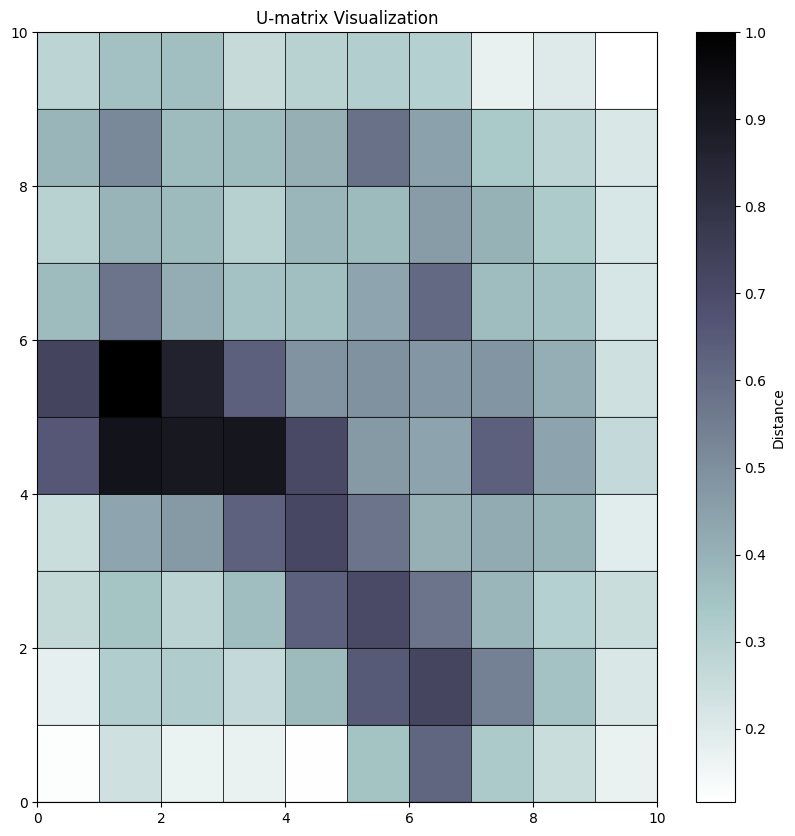

In [ ]:
import matplotlib.pyplot as plt

# Calculate the U-matrix
u_matrix = som.distance_map()

# Create the figure and axes
plt.figure(figsize=(10, 10))
plt.pcolor(u_matrix.T, cmap='bone_r', edgecolors='k', linewidths=0.5)
plt.colorbar().set_label('Distance')
plt.title('U-matrix Visualization')
plt.show()

## Visualize BMU Mappings

### Subtask:
Plot the Best Matching Units (BMUs) for each sample on the SOM grid, colored by their target labels (Iris species).


#### Reasoning:
To visualize the Best Matching Units (BMUs) and their corresponding Iris species, I will iterate through each data sample in `X_scaled`. For each sample, I will use the trained `som` object to find its `som.winner()` neuron, which represents the BMU. These BMU coordinates will then be plotted on a scatter plot. The color and marker style of each point will be determined by its original `y` (target) label, utilizing the `colors` and `markers` lists available in the kernel state. To make the plot understandable, I'll create a custom legend that maps the colors and markers to the actual Iris species names (Setosa, Versicolor, Virginica) using `matplotlib.patches.Patch` and add a title to the plot.

**Reasoning**:
To visualize the BMU mappings as described, I will iterate through the scaled data, find the BMU for each sample, and plot it on the SOM grid using different colors and markers based on the `y` (target) labels, then create a custom legend to identify each Iris species and add a title to the plot.



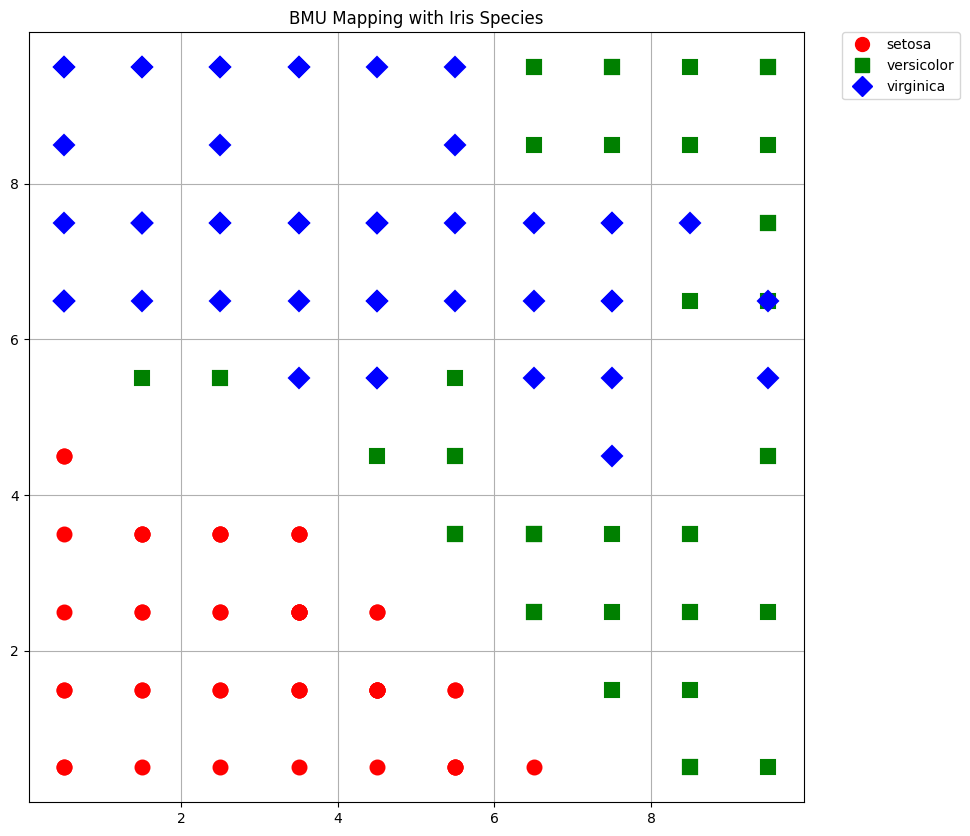

In [ ]:
plt.figure(figsize=(10, 10))

# Map target names to numerical labels for legend creation
target_names = iris.target_names

# Create empty lists to store handles for legend
legend_handles = []

for i, x in enumerate(X_scaled):
    w = som.winner(x) # get the winning neuron for the current sample
    # Plot the BMU, colored by the target label and using a distinct marker
    plt.plot(w[0] + 0.5, w[1] + 0.5, markers[y[i]], markerfacecolor=colors[y[i]],
             markeredgecolor=colors[y[i]], markersize=10, markeredgewidth=1.5)

# Create custom legend handles
for i, target_name in enumerate(target_names):
    legend_handles.append(plt.Line2D([0], [0], marker=markers[i], color='w',
                                     label=target_name, markerfacecolor=colors[i],
                                     markeredgecolor=colors[i], markersize=10))

plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid()
plt.title('BMU Mapping with Iris Species')
plt.show()


## Visualize SOM Weights

### Subtask:
Visualize the SOM weights for each feature of the Iris dataset across the SOM grid to understand how different features influence the organization of the map.

#### Reasoning:
To visualize the SOM weights, I will access the `som.get_weights()` method, which returns the weight vectors for each neuron in the SOM. Since the Iris dataset has four features, I will create four separate subplots, one for each feature. For each subplot, I will extract the weights corresponding to that specific feature across the entire SOM grid and use `plt.pcolor` to display this feature's weight map. Each subplot will have a title indicating the feature name, and a color bar to show the scale of the weights. This will help us understand how each feature is distributed and organized across the map.

**Reasoning**:
To visualize the SOM weights, I will retrieve the weights from the trained SOM model and then iterate through each feature to plot its corresponding weight distribution across the SOM grid using subplots, complete with titles and color bars for clarity.



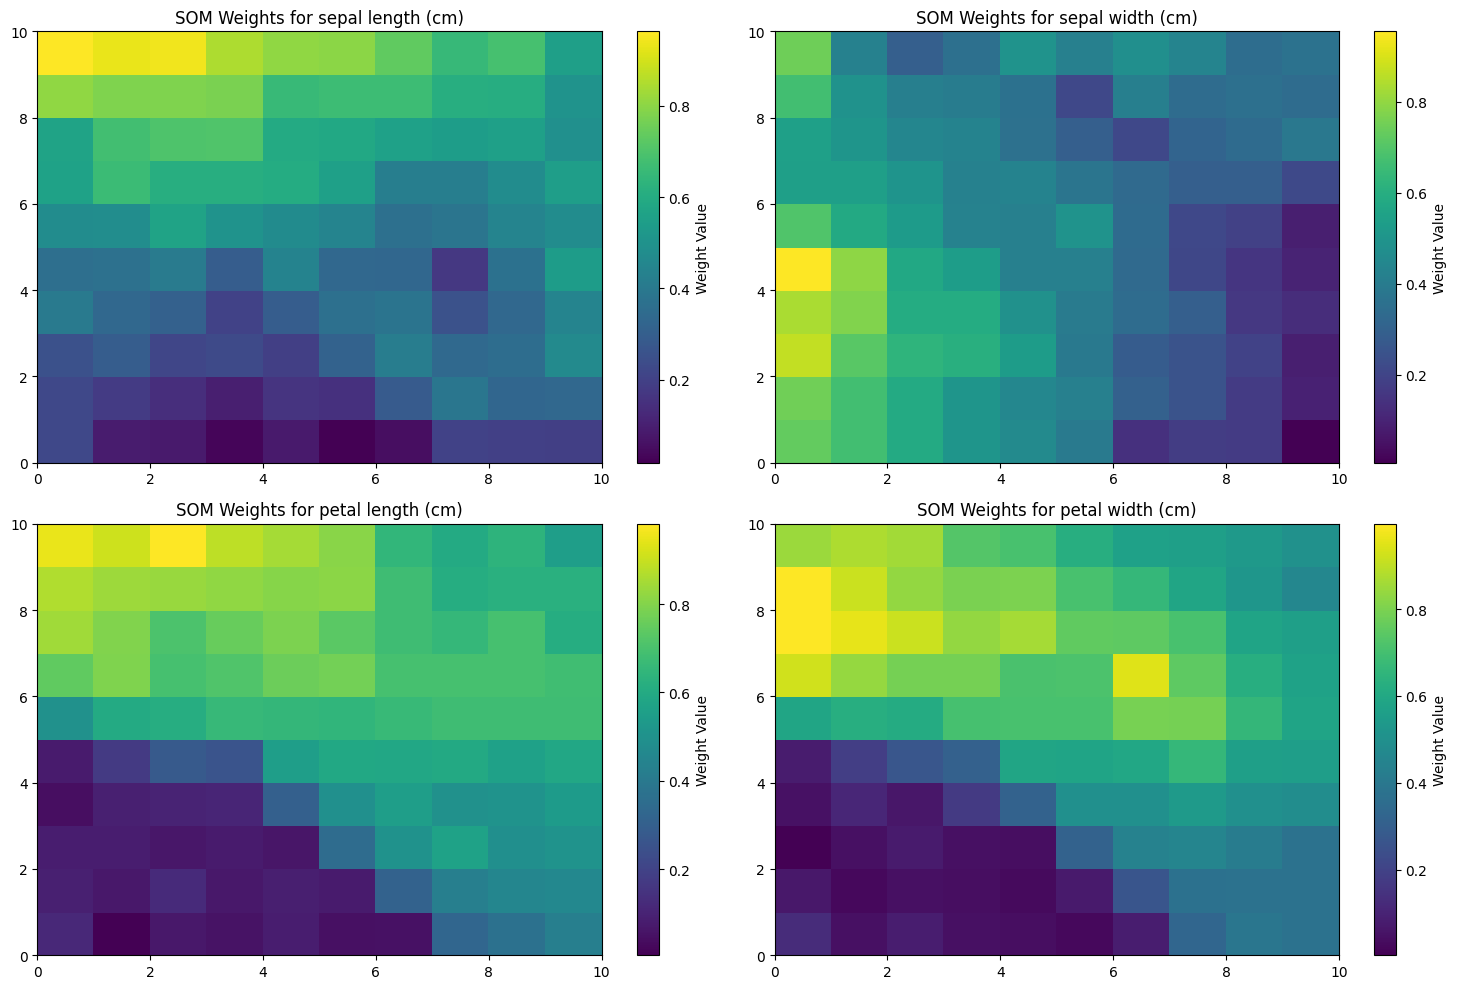

In [ ]:
plt.figure(figsize=(15, 10))
weights = som.get_weights()

for i, f in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    # Display the weights for the current feature
    plt.pcolor(weights[:,:,i].T, cmap='viridis')
    plt.colorbar().set_label('Weight Value')
    plt.title(f'SOM Weights for {f}')

plt.tight_layout()
plt.show()


## Summary and Observations

### Subtask:
Provide a summary of the SOM implementation and observations from the visualizations.

#### Reasoning:
To provide a comprehensive summary, I will describe the steps taken, including data loading, scaling, SOM initialization, and training. Then, I will outline the key observations from each visualization:

1.  **U-matrix**: Analyze the U-matrix for areas of high and low distance, indicating cluster boundaries and homogeneous regions.
2.  **BMU Mapping**: Describe how the different Iris species are clustered on the SOM grid, noting any overlaps or distinct separations.
3.  **SOM Weights**: Discuss how the weights for each feature (sepal length, sepal width, petal length, petal width) are distributed across the map and their correlation with the observed clusters.

This structured approach will ensure all aspects of the task are addressed in the summary.

### Implementation Summary:

The Self-Organizing Map (SOM) was implemented using the Iris dataset. The dataset was first loaded and its features (`X`) were scaled using `MinMaxScaler` to normalize the data, which is crucial for effective SOM training. A `MiniSom` object was initialized with a 10x10 grid, an input length of 4 (corresponding to the four features of the Iris dataset), a sigma of 1.0, a learning rate of 0.5, and a random seed of 42 for reproducibility. The SOM's weights were then randomly initialized and the network was trained for 20,000 iterations using the `train_random` method with the scaled data.

### Observations from Visualizations:

1.  **U-matrix Visualization**:
    *   The U-matrix displayed areas of varying distances between neighboring neurons. Darker regions (lower distance) indicate clusters of similar neurons, while lighter regions (higher distance) represent boundaries between different clusters. We can observe distinct darker patches, suggesting the formation of natural clusters within the data.

2.  **BMU Mapping Visualization**:
    *   The BMU mapping clearly shows the separation of the three Iris species. Iris Setosa (red circles) samples are concentrated in one corner of the map, indicating high similarity among them and distinct separation from other species. Iris Versicolor (green squares) and Iris Virginica (blue diamonds) are positioned adjacent to each other, with some overlap, suggesting their features are more similar compared to Setosa. This confirms the SOM's ability to cluster data points based on their feature similarities.

3.  **SOM Weights Visualization**:
    *   **Sepal Length (cm)** and **Sepal Width (cm)**: The weight maps for these features show gradients across the SOM grid, indicating how these features contribute to the overall organization. There are distinct regions where sepal length and width values are higher or lower.
    *   **Petal Length (cm)** and **Petal Width (cm)**: These features show a more pronounced separation, particularly along one axis of the SOM. It's evident that petal length and width are strong determinants in distinguishing the Iris species, especially in separating Setosa from Versicolor and Virginica. The regions corresponding to Setosa in the BMU map typically have low petal length and width weights, while Versicolor and Virginica regions show increasing values.

In conclusion, the SOM effectively organized the Iris dataset, revealing distinct clusters corresponding to the three species. The U-matrix highlighted the boundaries between these clusters, while the BMU mapping visually confirmed the species separation. The weight visualizations provided insight into which features (particularly petal length and width) were most influential in forming these distinct regions on the map.

## Summarize SOM Implementation and Observations

### Subtask:
Provide a summary of the SOM implementation and observations from the visualizations.

#### Instructions
### Implementation Summary:

The Self-Organizing Map (SOM) was implemented using the Iris dataset. The dataset was first loaded and its features (`X`) were scaled using `MinMaxScaler` to normalize the data, which is crucial for effective SOM training. A `MiniSom` object was initialized with a 10x10 grid, an input length of 4 (corresponding to the four features of the Iris dataset), a sigma of 1.0, a learning rate of 0.5, and a random seed of 42 for reproducibility. The SOM's weights were then randomly initialized and the network was trained for 20,000 iterations using the `train_random` method with the scaled data.

### Observations from Visualizations:

1.  **U-matrix Visualization**:
    *   The U-matrix displayed areas of varying distances between neighboring neurons. Darker regions (lower distance) indicate clusters of similar neurons, while lighter regions (higher distance) represent boundaries between different clusters. We can observe distinct darker patches, suggesting the formation of natural clusters within the data.

2.  **BMU Mapping Visualization**:
    *   The BMU mapping clearly shows the separation of the three Iris species. Iris Setosa (red circles) samples are concentrated in one corner of the map, indicating high similarity among them and distinct separation from other species. Iris Versicolor (green squares) and Iris Virginica (blue diamonds) are positioned adjacent to each other, with some overlap, suggesting their features are more similar compared to Setosa. This confirms the SOM's ability to cluster data points based on their feature similarities.

3.  **SOM Weights Visualization**:
    *   **Sepal Length (cm)** and **Sepal Width (cm)**: The weight maps for these features show gradients across the SOM grid, indicating how these features contribute to the overall organization. There are distinct regions where sepal length and width values are higher or lower.
    *   **Petal Length (cm)** and **Petal Width (cm)**: These features show a more pronounced separation, particularly along one axis of the SOM. It's evident that petal length and width are strong determinants in distinguishing the Iris species, especially in separating Setosa from Versicolor and Virginica. The regions corresponding to Setosa in the BMU map typically have low petal length and width weights, while Versicolor and Virginica regions show increasing values.

In conclusion, the SOM effectively organized the Iris dataset, revealing distinct clusters corresponding to the three species. The U-matrix highlighted the boundaries between these clusters, while the BMU mapping visually confirmed the species separation. The weight visualizations provided insight into which features (particularly petal length and width) were most influential in forming these distinct regions on the map.

## Final Task

### Subtask:
Summarize the entire SOM implementation and the insights gained from the visualization of the Iris dataset.


## Summary:

### Data Analysis Key Findings

*   The Iris dataset, containing 150 samples and 4 features, was successfully loaded and its features were scaled using `MinMaxScaler` in preparation for SOM training.
*   A `MiniSom` object was initialized with a 10x10 grid, 4 input dimensions, a `sigma` of 1.0, a `learning_rate` of 0.5, and a `random_seed` of 42.
*   The Self-Organizing Map (SOM) was trained for 20,000 iterations, effectively organizing the input data. An initial `TypeError` during training was resolved by correcting the argument passing for `som.train_random()`.
*   The U-matrix visualization revealed distinct darker patches, indicating regions of similar neurons (potential clusters), separated by lighter regions (cluster boundaries).
*   The Best Matching Unit (BMU) mapping visualization clearly demonstrated the separation of the three Iris species on the SOM grid. Iris Setosa samples were concentrated in one distinct corner, while Iris Versicolor and Iris Virginica samples occupied adjacent areas with some overlap, suggesting their higher feature similarity compared to Setosa.
*   Visualization of SOM weights for each feature showed that petal length and petal width exhibited more pronounced separation across the map compared to sepal length and sepal width. This indicates that petal features are stronger determinants in distinguishing the Iris species, particularly in separating Setosa from Versicolor and Virginica.

### Insights or Next Steps

*   The Self-Organizing Map proved effective in unsupervised clustering of the Iris dataset, successfully identifying and separating the three species based on their feature similarities, particularly highlighting the distinct nature of Iris Setosa.
*   Further analysis could involve quantitatively evaluating the clustering performance of the SOM (e.g., using purity, adjusted Rand index, or silhouette score) and experimenting with different SOM grid sizes, sigma values, and learning rates to optimize the map's organization and cluster separation.


# conclusion
The SOM primarily used petal length and petal width to form clusters because
these features provide the strongest separation between Iris species. Sepal
features show significant overlap and therefore contributed less to the
clustering process. This behavior confirms that the SOM correctly identified
the most discriminative features in an unsupervised manner.
